### 📘 Ensemble Learning: Bagging, Random Forest, and Boosting - Q&A

**1. Can we use Bagging for regression problems?**  
Yes, Bagging can be used for regression problems using models like `BaggingRegressor`, which aggregates predictions by averaging the outputs of multiple base regressors.

---

**2. What is the difference between multiple model training and single model training?**  
- **Single model training** trains one model on the entire dataset.  
- **Multiple model training** involves training several models on different subsets or views of the data to improve robustness and reduce overfitting (e.g., ensemble methods like Bagging, Boosting).

---

**3. Explain the concept of feature randomness in Random Forest.**  
In Random Forest, each decision tree is trained on a **random subset of features** at each split, which reduces correlation between trees and helps prevent overfitting.

---

**4. What is OOB (Out-of-Bag) Score?**  
OOB score is a validation score computed from the **bootstrap sampling** process in Bagging/Random Forest. Each tree is evaluated on the samples not used in its training, providing an unbiased performance estimate.

---

**5. How can you measure the importance of features in a Random Forest model?**  
Feature importance can be measured using:
- **Gini importance** (based on how much a feature reduces impurity across all trees)
- **Permutation importance** (measuring drop in model accuracy when a feature’s values are shuffled)

---

**6. Explain the working principle of a Bagging Classifier.**  
A Bagging Classifier trains multiple base classifiers (like Decision Trees) on **randomly bootstrapped subsets** of the data and combines their predictions using **majority voting** to improve accuracy and reduce variance.

---

**7. How do you evaluate a Bagging Classifier’s performance?**  
By using standard metrics like:
- **Accuracy, Precision, Recall, F1-score** (for classification)
- **Cross-validation or Out-of-Bag score** to assess generalization

---

**8. How does a Bagging Regressor work?**  
It fits multiple regressors on different random subsets (bootstrapped samples) and **averages their predictions** to produce a final output, reducing variance and improving stability.

---

**9. What is the main advantage of ensemble techniques?**  
They provide **better generalization** and **higher predictive accuracy** by combining multiple models to reduce variance, bias, or both.

---

**10. What is the main challenge of ensemble methods?**  
They can be **computationally expensive** and **harder to interpret**, especially with many base models. Training time and memory usage can be high.

---

**11. Explain the key idea behind ensemble techniques.**  
The idea is to **combine multiple weak learners** to create a strong learner that performs better than any individual model by leveraging diversity and aggregation.

---

**12. What is a Random Forest Classifier?**  
A Random Forest Classifier is an ensemble method that builds **many decision trees** using Bagging and random feature selection, and predicts via **majority voting**.

---

**13. What are the main types of ensemble techniques?**  
- **Bagging (Bootstrap Aggregating)**  
- **Boosting (e.g., AdaBoost, Gradient Boosting)**  
- **Stacking (stacked generalization)**

---

**14. What is ensemble learning in machine learning?**  
It is a technique where **multiple models (learners)** are combined to solve a problem more accurately than a single model by averaging, voting, or stacking their predictions.

---

**15. When should we avoid using ensemble methods?**  
- When **interpretability** is a top priority  
- When **training data is small**, and overfitting is not a concern  
- When **computational resources are limited**

---

**16. How does Bagging help in reducing overfitting?**  
By training models on **different random subsets** (with replacement), Bagging reduces variance and prevents overfitting of high-variance models like Decision Trees.

---

**17. Why is Random Forest better than a single Decision Tree?**  
It reduces overfitting and variance by averaging predictions across many de-correlated trees, resulting in **better accuracy and stability**.

---

**18. What is the role of bootstrap sampling in Bagging?**  
Bootstrap sampling creates **random subsets of the training data with replacement**, allowing each base learner to learn from slightly different data distributions.

---

**19. What are some real-world applications of ensemble techniques?**  
- Spam detection  
- Credit risk scoring  
- Fraud detection  
- Medical diagnosis  
- Stock price prediction  
- Image recognition

---

**20. What is the difference between Bagging and Boosting?**  
| Feature     | Bagging                     | Boosting                     |
|-------------|-----------------------------|------------------------------|
| Data Sampling | Random + with replacement | Sequential + weighted        |
| Model Training | Independent models         | Models correct previous errors |
| Goal        | Reduce variance             | Reduce bias and variance     |
| Example     | Random Forest               | AdaBoost, Gradient Boosting  |


****Practical Questions***

In [1]:
from sklearn.ensemble import BaggingClassifier,BaggingRegressor
from sklearn.ensemble import RandomForestClassifier ,RandomForestRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.datasets import make_classification,make_regression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,classification_report,mean_squared_error,auc,roc_auc_score,precision_recall_curve,roc_curve,r2_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.datasets import load_breast_cancer,load_iris
#classification data
X,y =make_classification(n_features=4,n_samples=1000,n_classes=2,random_state=42)
X_classificat_train,X_classificat_test,y_classificat_train,y_classificat_test=train_test_split(X,y,test_size=0.2,random_state=42)

#regressin data
X,y =make_regression(n_features=4,n_samples=1000,shuffle=True,random_state=42)
X_regressor_train,X_regressor_test,y_regressor_train,y_regressor_test=train_test_split(X,y,test_size=0.2,random_state=42)

import warnings
warnings.filterwarnings('ignore')


In [2]:
#21 Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy

model =BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=20,bootstrap=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

Accuracy of model is : 0.92


In [3]:
#22 Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)
model =BaggingRegressor(estimator=DecisionTreeRegressor(),n_estimators=10,bootstrap=True)
model.fit(X_regressor_train,y_regressor_train)
print("Accuracy of model is :",mean_squared_error(y_regressor_test,model.predict(X_regressor_test)))

Accuracy of model is : 622.2097666961807


In [4]:
#23 Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores
X,y=load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier(n_estimators=100,criterion="gini",oob_score=True)
model.fit(X_train,y_train)
print("accuracy :",accuracy_score(y_test,model.predict(X_test)))
print("feature importance : ",model.feature_importances_)

accuracy : 0.956140350877193
feature importance :  [0.01775427 0.01461753 0.04623042 0.04123373 0.00685168 0.0127295
 0.04140345 0.13621336 0.00212781 0.00453876 0.01104003 0.00368932
 0.0223724  0.00941117 0.00504884 0.00495192 0.00493056 0.00789747
 0.00337554 0.00781882 0.09162743 0.01771851 0.13265004 0.10294593
 0.01223071 0.01615358 0.04046419 0.1634923  0.01100822 0.00747253]


In [5]:
#24 Train a Random Forest Regressor and compare its performance with a single Decision Tree
#random forest
model =BaggingRegressor(estimator=DecisionTreeRegressor(),n_estimators=10,bootstrap=True)
model.fit(X_regressor_train,y_regressor_train)
print("Accuracy of random forest model is :",mean_squared_error(y_regressor_test,model.predict(X_regressor_test)))

#single decision tree
model2=DecisionTreeRegressor(splitter="best")
model2.fit(X_regressor_train,y_regressor_train)
print("Accuracy of single decision tree model is :",mean_squared_error(y_regressor_test,model2.predict(X_regressor_test)))

Accuracy of random forest model is : 517.3641042935055
Accuracy of single decision tree model is : 1412.2257379729608


In [6]:
#25	Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier

model =BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=10,bootstrap=True,oob_score=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))
print(" the Out-of-Bag (OOB) Score for a Random Forest Classifier",model.oob_score_)

Accuracy of model is : 0.915
 the Out-of-Bag (OOB) Score for a Random Forest Classifier 0.8825


In [7]:
#26 Train a Bagging Classifier using SVM as a base estimator and print accuracy
from sklearn.svm import SVC
model =BaggingClassifier(estimator=SVC(),n_estimators=200,bootstrap=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

Accuracy of model is : 0.89


In [8]:
#27 Train a Random Forest Classifier with different numbers of trees and compare accuracy
model =BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=10,bootstrap=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model n_estimators=10 is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

model =BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,bootstrap=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model n_estimators=50 is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

model =BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,bootstrap=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model n_estimators=100 is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

model =BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,bootstrap=True)
model.fit(X_classificat_train,y_classificat_train)
print("Accuracy of model n_estimators=200 is :",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

Accuracy of model n_estimators=10 is : 0.915
Accuracy of model n_estimators=50 is : 0.935
Accuracy of model n_estimators=100 is : 0.935
Accuracy of model n_estimators=200 is : 0.935


In [9]:
#28 Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score
from sklearn.linear_model import LogisticRegression
model= BaggingClassifier(LogisticRegression(),n_estimators=50)
model.fit(X_classificat_train,y_classificat_train)
y_pred=model.predict(X_classificat_test)
print("Accuracy of model n_estimators=50 is :",accuracy_score(y_classificat_test,y_pred))
fpr, tpr, thresholds = roc_curve(y_classificat_test,model.predict_proba(X_classificat_test)[:,1])
print(" AUC score",auc(fpr,tpr))

Accuracy of model n_estimators=50 is : 0.885
 AUC score 0.9522952295229522


In [10]:
#29 Train a Random Forest Regressor and analyze feature importance scores
model=RandomForestRegressor(n_estimators=50)
model.fit(X_regressor_train,y_regressor_train)
print("Accuracy of random forest model is :",mean_squared_error(y_regressor_test,model.predict(X_regressor_test)))
print("feature importance scores",model.feature_importances_)

Accuracy of random forest model is : 425.08370491036663
feature importance scores [0.14169398 0.1780781  0.67085061 0.00937731]


In [11]:
#30 Train an ensemble model using both Bagging and Random Forest and compare accuracy
model= BaggingClassifier(DecisionTreeClassifier(),n_estimators=50)
model.fit(X_classificat_train,y_classificat_train)
y_pred=model.predict(X_classificat_test)
print("Accuracy of Bagging model is :",accuracy_score(y_classificat_test,y_pred))

model=RandomForestClassifier(n_estimators=50,criterion="gini",oob_score=True)
model.fit(X_classificat_train,y_classificat_train)
print("accuracy Random Forest:",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))

Accuracy of Bagging model is : 0.935
accuracy Random Forest: 0.94


In [12]:
#31  Train a Random Forest Classifier and tune hyperparameters using GridSearchCV=
from sklearn.model_selection import GridSearchCV
param ={
    "n_estimators":[10,25,50],
    'criterion':['gini',"log_loss"],   
    'max_features':['sqrt',"log2", None], 
    'bootstrap':[True,False],
    "ccp_alpha":[.2,.5,1]
}
model= GridSearchCV(RandomForestClassifier(),param_grid=param,cv=5,scoring="accuracy",n_jobs=-1)
model.fit(X_classificat_train,y_classificat_train)
y_pred=model.predict(X_classificat_test)
print("Accuracy of best model is :",accuracy_score(y_classificat_test,y_pred))
print("best params are : ",model.best_params_)

Accuracy of best model is : 0.89
best params are :  {'bootstrap': True, 'ccp_alpha': 0.2, 'criterion': 'gini', 'max_features': None, 'n_estimators': 25}


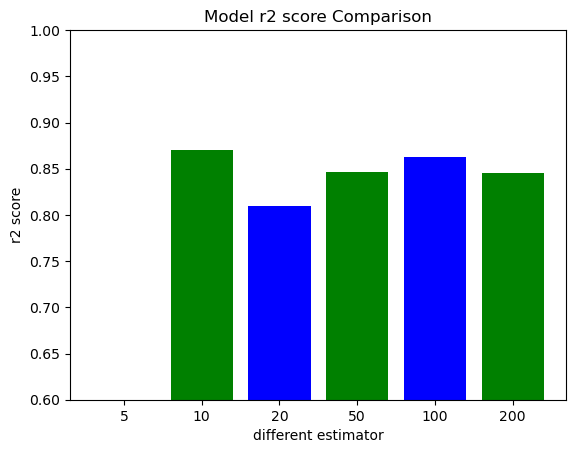

In [13]:
#32= Train a Bagging Regressor with different numbers of base estimators and compare performance=
different_n_estimator =[5,10,20,50,100,200]
performance=[]
for i in different_n_estimator:
    model=BaggingRegressor(DecisionTreeRegressor(),n_estimators=i,bootstrap_features=True)
    model.fit(X_regressor_train,y_regressor_train)
    y_pred = model.predict(X_regressor_test)
    performance.append(r2_score(y_regressor_test,y_pred))

import matplotlib.pyplot as plt
plt.bar([str(i) for i in different_n_estimator],performance,color=['blue', 'green'])
plt.ylabel('r2 score')
plt.xlabel('different estimator')
plt.title('Model r2 score Comparison')
plt.ylim(0.6, 1.0)
plt.show()    

In [14]:
#33 Train a Random Forest Classifier and analyze misclassified samples=
import  pandas as pd
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Analyze Misclassified Samples
misclassified_indices = (y_pred != y_test)
misclassified_samples = X_test[misclassified_indices]
misclassified_true = y_test[misclassified_indices]
misclassified_pred = y_pred[misclassified_indices]

print("\nTotal misclassified samples:", len(misclassified_samples))
misclassified_df = pd.DataFrame(
    misclassified_samples,
    columns=data.feature_names
)

misclassified_df = pd.DataFrame(
    misclassified_samples,
    columns=data.feature_names
)
misclassified_df['True Label'] = misclassified_true
misclassified_df['Predicted Label'] = misclassified_pred
misclassified_df

Accuracy: 0.9649122807017544

Total misclassified samples: 4


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,True Label,Predicted Label
0,13.34,15.86,86.49,520.0,0.10780,0.15350,0.11690,0.06987,0.1942,0.06902,...,96.66,614.9,0.1536,0.4791,0.4858,0.1708,0.3527,0.10160,1,0
1,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,110.30,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,0,1
2,13.96,17.05,91.43,602.4,0.10960,0.12790,0.09789,0.05246,0.1908,0.06130,...,108.10,826.0,0.1512,0.3262,0.3209,0.1374,0.3068,0.07957,0,1
3,14.48,21.46,94.25,648.2,0.09444,0.09947,0.12040,0.04938,0.2075,0.05636,...,108.40,808.9,0.1306,0.1976,0.3349,0.1225,0.3020,0.06846,0,1


In [15]:
#34= Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier=
model= BaggingClassifier(DecisionTreeClassifier(),n_estimators=100)
model.fit(X_classificat_train,y_classificat_train)
y_pred=model.predict(X_classificat_test)
print("Accuracy of Bagging Classifier model is :",accuracy_score(y_classificat_test,y_pred))

model= DecisionTreeClassifier()
model.fit(X_classificat_train,y_classificat_train)
print("accuracy single Decision Tree Classifier=:",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))


Accuracy of Bagging Classifier model is : 0.935
accuracy single Decision Tree Classifier=: 0.92


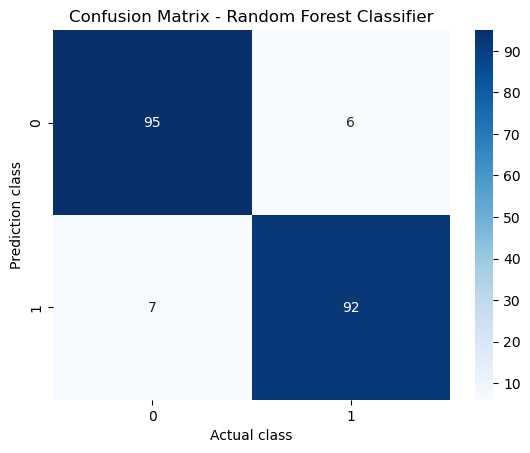

In [16]:
#35= Train a Random Forest Classifier and visualize the confusion matrix=

model= RandomForestClassifier()
model.fit(X_classificat_train,y_classificat_train)
import seaborn as sns
sns.heatmap(confusion_matrix(y_classificat_test,model.predict(X_classificat_test)),annot=True,cmap="Blues")
plt.xlabel("Actual class")
plt.ylabel("Prediction class")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()


In [17]:
#36= Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy=
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

estimator=[
    ("Logistic",LogisticRegression()),
    ("SVM",SVC(probability=True)),
    ("Decision tree",DecisionTreeClassifier())    
]
model=StackingClassifier(estimators=estimator,final_estimator=LogisticRegression(),cv=5,n_jobs=-1)
model.fit(X_classificat_train,y_classificat_train)
print("accuracy single Decision Tree Classifier=:",accuracy_score(y_classificat_test,model.predict(X_classificat_test)))


accuracy single Decision Tree Classifier=: 0.93


In [18]:
#37 Train a Random Forest Classifier and print the top 5 most important features=
import numpy as np
X,y=make_classification(n_classes=2,n_samples=1000,n_features=10)
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier(n_estimators=100,criterion="gini",oob_score=True)
model.fit(X_train,y_train)
print("accuracy :",accuracy_score(y_test,model.predict(X_test)))
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

print("Top 5 Feature Importances:")
for i in range(5):
    print(f"Feature {indices[i]}: {importances[indices[i]]:.4f}")


accuracy : 0.935
Top 5 Feature Importances:
Feature 8: 0.3395
Feature 2: 0.2750
Feature 7: 0.1992
Feature 4: 0.0482
Feature 3: 0.0265


In [19]:
#38= Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score=
model=BaggingClassifier()
model.fit(X_classificat_train,y_classificat_train)
y_pred=model.predict(X_classificat_test)
print("Accuracy   :", accuracy_score(y_classificat_test, y_pred))
print("Precision  :", precision_score(y_classificat_test, y_pred))
print("Recall     :", recall_score(y_classificat_test, y_pred))
print("F1-Score   :", f1_score(y_classificat_test, y_pred))

Accuracy   : 0.93
Precision  : 0.956989247311828
Recall     : 0.898989898989899
F1-Score   : 0.9270833333333334


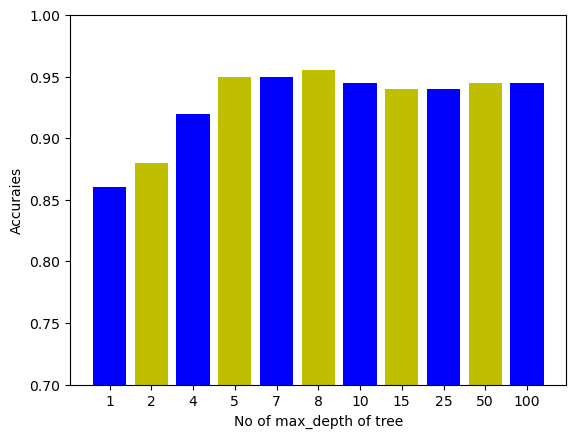

In [20]:
#39= Train a Random Forest Classifier and analyze the effect of max_depth on accuracy=
max_depth=[1,2,4,5,7,8,10,15,25,50,100]
accuracies=[]
for i in max_depth:
    model=RandomForestClassifier(max_depth=i,n_jobs=-1,n_estimators=100)
    model.fit(X_classificat_train,y_classificat_train)
    y_pred=model.predict(X_classificat_test)
    acc=accuracy_score(y_classificat_test,y_pred)
    accuracies.append(acc)

plt.bar([str(i) for i in max_depth],accuracies,color=['b','y'])
plt.xlabel("No of max_depth of tree")
plt.ylabel("Accuraies")
plt.ylim(.7,1)
plt.show()
        

In [21]:
#40= Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance=
model=BaggingRegressor(estimator=DecisionTreeRegressor(),n_estimators=50,bootstrap=True)
model.fit(X_regressor_train,y_regressor_train)
y_pred=model.predict(X_regressor_test)
print("accuracy base estimators DecisionTree=:",r2_score(y_regressor_test,y_pred))

from sklearn.neighbors import KNeighborsRegressor
model=BaggingRegressor(KNeighborsRegressor(),n_jobs=-1,n_estimators=50)
model.fit(X_regressor_train,y_regressor_train)
y_pred=model.predict(X_regressor_test)
print("accuracy base estimators KNeighbors=:",r2_score(y_regressor_test,y_pred))

accuracy base estimators DecisionTree=: 0.9733719727979139
accuracy base estimators KNeighbors=: 0.9549514114956453


In [22]:
#41 Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score=
X,y=make_classification(n_classes=2,n_samples=1000,n_features=10)
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier(n_estimators=100,criterion="gini",oob_score=True)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("accuracy :",accuracy_score(y_test,y_pred))
y_pred_prob=model.predict_proba(X_test)[:,1]
print("Accuracy       :", accuracy_score(y_test, y_pred))
print("ROC-AUC Score  :", roc_auc_score(y_test, y_pred_prob))

accuracy : 0.96
Accuracy       : 0.96
ROC-AUC Score  : 0.9904761904761905


In [23]:
#42 Train a Bagging Classifier and evaluate its performance using cross-validation.
from sklearn.model_selection import StratifiedKFold,KFold,cross_val_score
cv =StratifiedKFold(n_splits=5,shuffle=True)

model=BaggingClassifier(n_estimators=50,estimator=DecisionTreeClassifier())

scores=cross_val_score(model,X_classificat_train,y_classificat_train,cv=cv)
print("performance using cross-validation.",scores)
print("Mean accuracy:", scores.mean())

performance using cross-validation. [0.88125 0.9125  0.8875  0.90625 0.925  ]
Mean accuracy: 0.9025000000000001


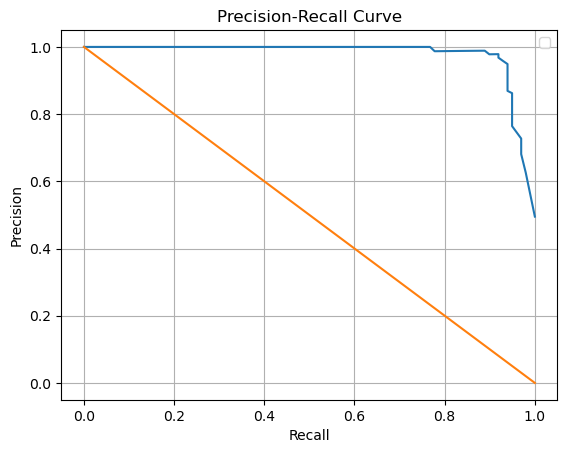

In [24]:
#43 Train a Random Forest Classifier and plot the Precision-Recall curv
model=RandomForestClassifier(n_estimators=50,n_jobs=-1)
model.fit(X_classificat_train,y_classificat_train)
y_pred_prob=model.predict_proba(X_classificat_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_classificat_test, y_pred_prob)

plt.plot(recall,precision)
plt.plot([1,0],[0,1])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
#44= Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy=
from sklearn.ensemble import StackingClassifier
estimators = [
    ('rf', RandomForestClassifier()),
    ('svc', SVC(probability=True))   
]
model= StackingClassifier(estimators=estimators,n_jobs=-1,final_estimator=LogisticRegression())
model.fit(X_classificat_train,y_classificat_train)
y_pred=model.predict(X_classificat_test)
print("Accuracy   :", accuracy_score(y_classificat_test, y_pred))

Accuracy   : 0.95


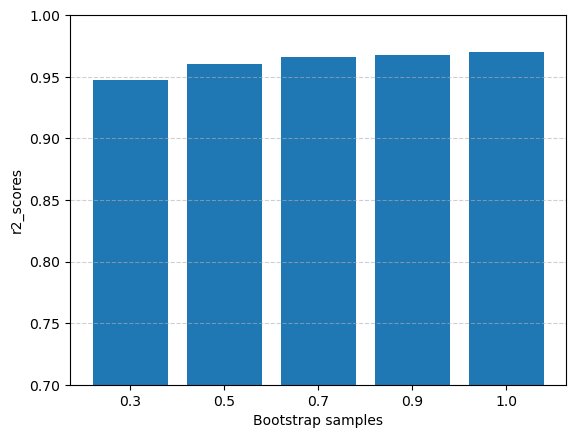

In [27]:
#45 Train a Bagging Regressor with different levels of bootstrap samples and compare performance.
bootstrap_samples = [0.3, 0.5, 0.7, 0.9, 1.0]  # as fraction of training set
r2_scores=[]
for i in bootstrap_samples:
    model=BaggingRegressor(estimator=RandomForestRegressor(),n_estimators=50,max_samples=i)
    model.fit(X_regressor_train,y_regressor_train)
    y_pred=model.predict(X_regressor_test)
    r2_scores.append(r2_score(y_regressor_test,y_pred))
plt.bar([str(i) for i in bootstrap_samples],r2_scores)
plt.ylim(.7,1)
plt.xlabel("Bootstrap samples")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylabel("r2_scores")

plt.show()